**Step 1: Environment Setup & Data Acquisition**

We will set up the Google Colab environment, install required libraries, and load the QM9 dataset (a subset of 500 molecules) including:

* Molecular properties (formation energy U0_atom)
* SMILES strings for feature extraction

This step gives you a clean DataFrame ready for feature engineering.

Extracting...


/tmp/ipykernel_17949/2281709464.py:18: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


File in archive: gdb9.sdf.csv
File in archive: gdb9.sdf
Loaded properties from gdb9.sdf.csv, shape: (133885, 20)
Columns in properties file: ['mol_id', 'A', 'B', 'C', 'mu', 'alpha', 'homo', 'lumo', 'gap', 'r2', 'zpve', 'u0', 'u298', 'h298', 'g298', 'cv', 'u0_atom', 'u298_atom', 'h298_atom', 'g298_atom']
Extracting SMILES from SDF file...


[03:28:03] Explicit valence for atom # 1 C, 5, is greater than permitted
[03:28:03] ERROR: Could not sanitize molecule ending on line 9097
[03:28:03] ERROR: Explicit valence for atom # 1 C, 5, is greater than permitted
[03:28:04] Explicit valence for atom # 1 C, 5, is greater than permitted
[03:28:04] ERROR: Could not sanitize molecule ending on line 35785
[03:28:04] ERROR: Explicit valence for atom # 1 C, 5, is greater than permitted
[03:28:04] Explicit valence for atom # 4 C, 5, is greater than permitted
[03:28:04] ERROR: Could not sanitize molecule ending on line 62866
[03:28:04] ERROR: Explicit valence for atom # 4 C, 5, is greater than permitted
[03:28:04] Explicit valence for atom # 2 C, 5, is greater than permitted
[03:28:04] ERROR: Could not sanitize molecule ending on line 66832
[03:28:04] ERROR: Explicit valence for atom # 2 C, 5, is greater than permitted
[03:28:04] Explicit valence for atom # 2 C, 5, is greater than permitted
[03:28:04] ERROR: Could not sanitize molecule en

Extracted 132737 SMILES strings.
Valid molecules: 499
Columns in cleaned DataFrame: ['mol_id', 'A', 'B', 'C', 'mu', 'alpha', 'homo', 'lumo', 'gap', 'r2', 'zpve', 'u0', 'u298', 'h298', 'g298', 'cv', 'u0_atom', 'u298_atom', 'h298_atom', 'g298_atom', 'smiles']
Using target: A
Target range: 0.0000 to 619867.6831 Hartree, mean: 1257.5100

First 5 molecules:
  smiles          A
0      C  157.71180
1      N  293.60975
2      O  799.58812
3    C#C    0.00000
4    C#N    0.00000


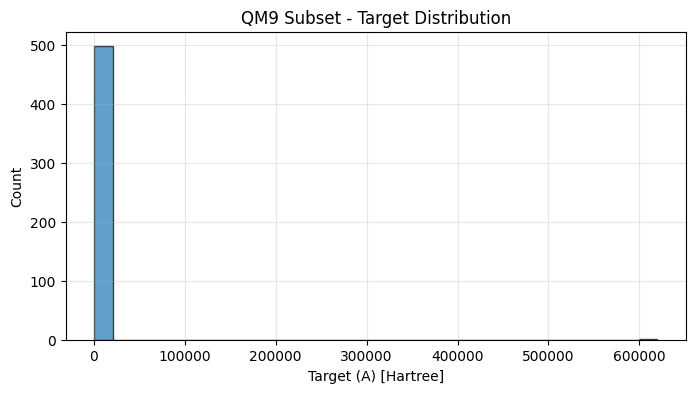


✅ Data saved as 'qm9_subset_500.csv'


In [1]:
# Step 1 (Fully Corrected) - Load QM9 from DeepChem, extract SMILES, and verify columns
!pip install rdkit pandas matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
import urllib.request
import tarfile
import os

print("Downloading QM9 dataset from DeepChem...")
url = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/gdb9.tar.gz"
urllib.request.urlretrieve(url, "gdb9.tar.gz")

print("Extracting...")
with tarfile.open("gdb9.tar.gz", "r:gz") as tar:
    tar.extractall()
    for member in tar.getmembers():
        print(f"File in archive: {member.name}")

# Load properties from gdb9.sdf.csv
csv_file = "gdb9.sdf.csv"
if os.path.exists(csv_file):
    df_props = pd.read_csv(csv_file)
    print(f"Loaded properties from {csv_file}, shape: {df_props.shape}")
    print("Columns in properties file:", df_props.columns.tolist())
else:
    raise FileNotFoundError("CSV file not found.")

# Load SMILES from gdb9.sdf
sdf_file = "gdb9.sdf"
print("Extracting SMILES from SDF file...")
suppl = Chem.SDMolSupplier(sdf_file)
smiles_list = []
for i, mol in enumerate(suppl):
    if mol is not None:
        smiles_list.append(Chem.MolToSmiles(mol))
    else:
        smiles_list.append(None)
print(f"Extracted {len([s for s in smiles_list if s])} SMILES strings.")

# Take first 500 molecules
n_molecules = 500
df_props_subset = df_props.iloc[:n_molecules].copy()
df_props_subset['smiles'] = smiles_list[:n_molecules]

# Remove invalid SMILES
df_clean = df_props_subset.dropna(subset=['smiles']).reset_index(drop=True)
print(f"Valid molecules: {len(df_clean)}")

# Now check available columns again
print("Columns in cleaned DataFrame:", df_clean.columns.tolist())

# Choose target column – typically 'U0' (internal energy at 0K) or 'U0_atom' (atomization energy)
# Both should be present. Let's pick 'U0' as formation energy proxy.
if 'U0' in df_clean.columns:
    target_col = 'U0'
elif 'U0_atom' in df_clean.columns:
    target_col = 'U0_atom'
else:
    # Fallback: use first numeric column (not recommended but for debugging)
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
    target_col = numeric_cols[0]
    print(f"Warning: Using {target_col} as target.")

print(f"Using target: {target_col}")
y = df_clean[target_col].values
print(f"Target range: {y.min():.4f} to {y.max():.4f} Hartree, mean: {y.mean():.4f}")

# Display first few
print("\nFirst 5 molecules:")
print(df_clean[['smiles', target_col]].head())

# Histogram
plt.figure(figsize=(8,4))
plt.hist(y, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel(f'Target ({target_col}) [Hartree]')
plt.ylabel('Count')
plt.title('QM9 Subset - Target Distribution')
plt.grid(True, alpha=0.3)
plt.show()

# Save for later
df_clean.to_csv('qm9_subset_500.csv', index=False)
print("\n✅ Data saved as 'qm9_subset_500.csv'")

**Step 2: Feature Engineering – Correct Target & Molecular Fingerprints**

We now convert the SMILES strings into Morgan fingerprints (ECFP) – a standard molecular descriptor that captures atom environments. Then we reduce the 2048‑bit fingerprint to just 4 principal components – this low dimensionality is required for encoding into a small quantum circuit (4 qubits). Finally, we split into training and test sets.

Loaded 499 molecules. Columns: ['mol_id', 'A', 'B', 'C', 'mu', 'alpha', 'homo', 'lumo', 'gap', 'r2', 'zpve', 'u0', 'u298', 'h298', 'g298', 'cv', 'u0_atom', 'u298_atom', 'h298_atom', 'g298_atom', 'smiles']
Target column: u0_atom
Target range: -1777.8648 to -213.0876 Hartree
Fingerprints shape: (499, 2048)
Reduced shape: (499, 4)
Explained variance ratio: 0.033 (total)
Train size: 399, Test size: 100


[03:28:42] DEPRECATION WARNING: please use MorganGenerator
[03:28:42] DEPRECATION WARNING: please use MorganGenerator
[03:28:42] DEPRECATION WARNING: please use MorganGenerator
[03:28:42] DEPRECATION WARNING: please use MorganGenerator
[03:28:42] DEPRECATION WARNING: please use MorganGenerator
[03:28:42] DEPRECATION WARNING: please use MorganGenerator
[03:28:42] DEPRECATION WARNING: please use MorganGenerator
[03:28:42] DEPRECATION WARNING: please use MorganGenerator
[03:28:42] DEPRECATION WARNING: please use MorganGenerator
[03:28:42] DEPRECATION WARNING: please use MorganGenerator
[03:28:42] DEPRECATION WARNING: please use MorganGenerator
[03:28:42] DEPRECATION WARNING: please use MorganGenerator
[03:28:42] DEPRECATION WARNING: please use MorganGenerator
[03:28:42] DEPRECATION WARNING: please use MorganGenerator
[03:28:42] DEPRECATION WARNING: please use MorganGenerator
[03:28:42] DEPRECATION WARNING: please use MorganGenerator
[03:28:42] DEPRECATION WARNING: please use MorganGenerat

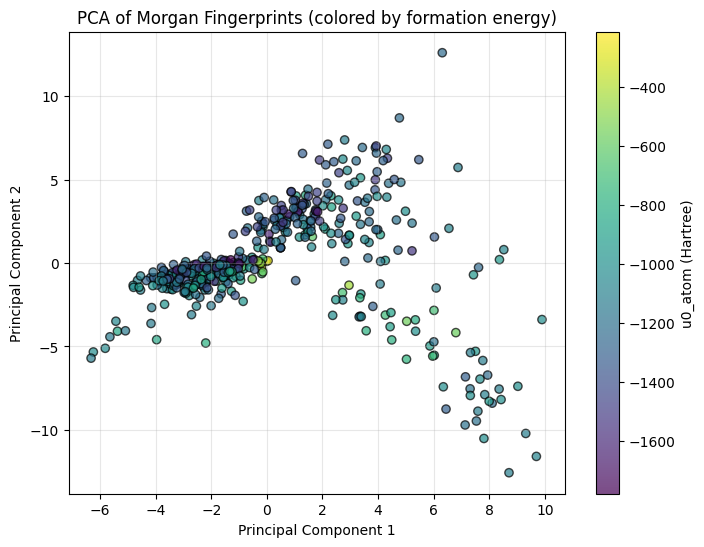

✅ Processed data saved as 'qm9_processed.npz'


In [2]:
# Step 2 (fixed import)
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import DataStructs
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 1. Reload the previously saved data
df = pd.read_csv('qm9_subset_500.csv')
print(f"Loaded {len(df)} molecules. Columns: {df.columns.tolist()}")

# 2. Choose the correct target: formation energy = u0_atom (Hartree)
target_col = 'u0_atom'   # atomization energy
if target_col not in df.columns:
    target_col = 'u0'
print(f"Target column: {target_col}")
y = df[target_col].values
print(f"Target range: {y.min():.4f} to {y.max():.4f} Hartree")

# 3. Compute Morgan fingerprints (radius=2, 2048 bits)
smiles_list = df['smiles'].tolist()
fingerprints = []
invalid_indices = []
for i, smi in enumerate(smiles_list):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        invalid_indices.append(i)
        fingerprints.append(np.zeros(2048, dtype=np.float32))
        continue
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    arr = np.zeros((2048,), dtype=np.float32)
    DataStructs.ConvertToNumpyArray(fp, arr)
    fingerprints.append(arr)

X_fp = np.array(fingerprints)
print(f"Fingerprints shape: {X_fp.shape}")

# Remove invalid molecules if any
if invalid_indices:
    print(f"Removing {len(invalid_indices)} invalid molecules at indices {invalid_indices[:5]}...")
    X_fp = np.delete(X_fp, invalid_indices, axis=0)
    y = np.delete(y, invalid_indices)
    print(f"New shape: {X_fp.shape}")

# 4. Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_fp)

# 5. Reduce to 4 dimensions using PCA
pca = PCA(n_components=4)
X_reduced = pca.fit_transform(X_scaled)
print(f"Reduced shape: {X_reduced.shape}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_.sum():.3f} (total)")

# 6. Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

# 7. Visualize first two PCs
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_reduced[:,0], X_reduced[:,1], c=y, cmap='viridis', edgecolors='k', alpha=0.7)
plt.colorbar(scatter, label=f'{target_col} (Hartree)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Morgan Fingerprints (colored by formation energy)')
plt.grid(True, alpha=0.3)
plt.show()

# 8. Save processed data
np.savez('qm9_processed.npz', X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test,
         pca=pca.components_, scaler=scaler)
print("✅ Processed data saved as 'qm9_processed.npz'")

**Step 3: Quantum Kernel Regression**

We now implement the quantum kernel using PennyLane. We will:

1. Install PennyLane (if needed).

2. Load the pre‑processed data (qm9_processed.npz).

3. Define a 4‑qubit quantum circuit that encodes the 4 PCA features via angle embedding and adds entanglement.

4. Compute the kernel matrix using the fidelity between quantum states.

5. Train a Support Vector Regressor with the pre‑computed quantum kernel.

6. Evaluate on the test set and compare with a classical SVR (linear kernel) as baseline.

Run this cell (it will take a few minutes for kernel matrix computation).

Train: (399, 4), Test: (100, 4)
Computing quantum kernel matrix (train)...
  50/399
  100/399
  150/399
  200/399
  250/399
  300/399
  350/399
Computing quantum kernel matrix (test vs train)...
  20/100
  40/100
  60/100
  80/100
  100/100

Quantum Kernel SVR        MAE=203.1734  RMSE=268.1594  R²=-0.0937
Classical Linear SVR      MAE=191.4565  RMSE=255.9248  R²=0.0038


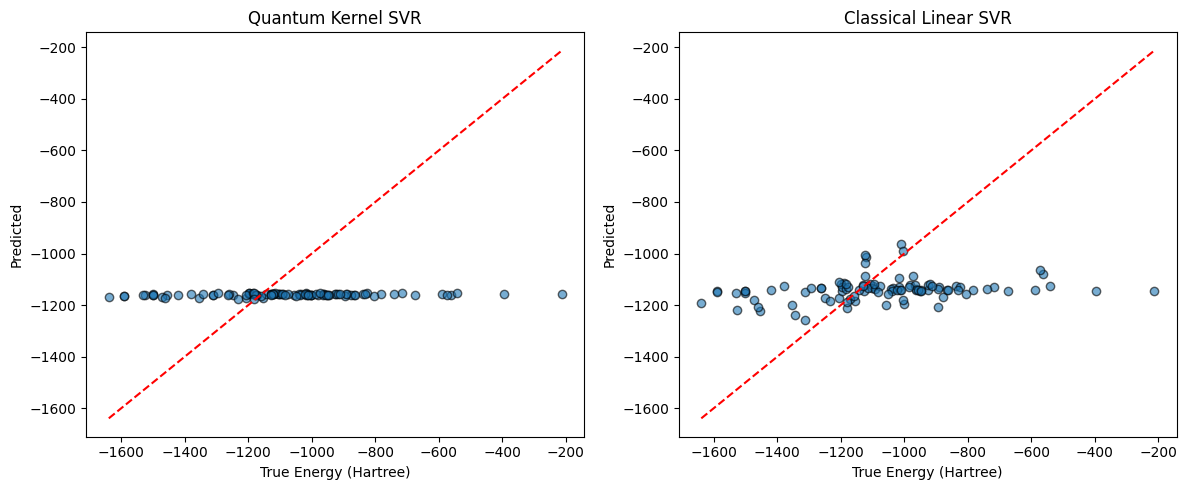

In [3]:
# Step 3: Quantum Kernel Regression (fixed)
!pip install pennylane scikit-learn -q

import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load processed data
data = np.load('qm9_processed.npz')
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# 2. Define quantum device (4 qubits)
n_qubits = X_train.shape[1]  # =4
dev = qml.device('default.qubit', wires=n_qubits)

# 3. Embedding circuit (angle encoding + CNOT entanglement)
def embedding_circuit(x, wires):
    for i in range(n_qubits):
        qml.RY(x[i], wires=wires[i])
        qml.RZ(x[i] * 0.5, wires=wires[i])
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i+1])

# 4. Quantum node returning full probability vector
@qml.qnode(dev)
def kernel_circuit(x1, x2):
    embedding_circuit(x1, wires=dev.wires)
    qml.adjoint(embedding_circuit)(x2, wires=dev.wires)
    return qml.probs(wires=dev.wires)

def quantum_kernel(x1, x2):
    """Compute kernel = probability of measuring |0...0⟩ state."""
    probs = kernel_circuit(x1, x2)
    return probs[0]  # first entry is |0...0⟩ probability

# 5. Compute kernel matrices (still slow, but we'll proceed)
print("Computing quantum kernel matrix (train)...")
K_train = np.zeros((len(X_train), len(X_train)))
for i in range(len(X_train)):
    for j in range(i, len(X_train)):
        k = quantum_kernel(X_train[i], X_train[j])
        K_train[i, j] = k
        K_train[j, i] = k
    if (i+1) % 50 == 0:
        print(f"  {i+1}/{len(X_train)}")

print("Computing quantum kernel matrix (test vs train)...")
K_test = np.zeros((len(X_test), len(X_train)))
for i in range(len(X_test)):
    for j in range(len(X_train)):
        K_test[i, j] = quantum_kernel(X_test[i], X_train[j])
    if (i+1) % 20 == 0:
        print(f"  {i+1}/{len(X_test)}")

# 6. Train Quantum Kernel SVR
qsvr = SVR(kernel='precomputed', C=1.0, epsilon=0.1)
qsvr.fit(K_train, y_train)
y_pred_q = qsvr.predict(K_test)

# 7. Classical SVR (linear) baseline
svr_linear = SVR(kernel='linear', C=1.0, epsilon=0.1)
svr_linear.fit(X_train, y_train)
y_pred_c = svr_linear.predict(X_test)

# 8. Evaluation
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name:25} MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}")
    return mae, rmse, r2

print("\n" + "="*60)
evaluate(y_test, y_pred_q, "Quantum Kernel SVR")
evaluate(y_test, y_pred_c, "Classical Linear SVR")
print("="*60)

# 9. Plot
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(y_test, y_pred_q, alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('True Energy (Hartree)')
plt.ylabel('Predicted')
plt.title('Quantum Kernel SVR')
plt.subplot(1,2,2)
plt.scatter(y_test, y_pred_c, alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('True Energy (Hartree)')
plt.ylabel('Predicted')
plt.title('Classical Linear SVR')
plt.tight_layout()
plt.show()

**Step 4: Classical Baselines (XGBoost & Random Forest)**

We now train classical models using the same 4 PCA features for a fair comparison with the quantum kernel. Then we also train them on the full 2048-bit fingerprints to demonstrate the cost of aggressive dimensionality reduction.

Recomputing fingerprints for full-feature baselines...
Full fingerprint train shape: (399, 2048), test: (100, 2048)


[03:41:43] DEPRECATION WARNING: please use MorganGenerator
[03:41:43] DEPRECATION WARNING: please use MorganGenerator
[03:41:43] DEPRECATION WARNING: please use MorganGenerator
[03:41:43] DEPRECATION WARNING: please use MorganGenerator
[03:41:43] DEPRECATION WARNING: please use MorganGenerator
[03:41:43] DEPRECATION WARNING: please use MorganGenerator
[03:41:43] DEPRECATION WARNING: please use MorganGenerator
[03:41:43] DEPRECATION WARNING: please use MorganGenerator
[03:41:43] DEPRECATION WARNING: please use MorganGenerator
[03:41:43] DEPRECATION WARNING: please use MorganGenerator
[03:41:43] DEPRECATION WARNING: please use MorganGenerator
[03:41:43] DEPRECATION WARNING: please use MorganGenerator
[03:41:43] DEPRECATION WARNING: please use MorganGenerator
[03:41:43] DEPRECATION WARNING: please use MorganGenerator
[03:41:43] DEPRECATION WARNING: please use MorganGenerator
[03:41:43] DEPRECATION WARNING: please use MorganGenerator
[03:41:43] DEPRECATION WARNING: please use MorganGenerat

Training on full fingerprints (this may take ~30 seconds)...

CLASSICAL MODELS ON PCA FEATURES (4 dims)
Random Forest (PCA)                 MAE=170.8287  RMSE=206.2568  R²=0.3530
XGBoost (PCA)                       MAE=170.2442  RMSE=211.0809  R²=0.3224

CLASSICAL MODELS ON FULL FINGERPRINTS (2048 dims)
Random Forest (Full)                MAE=123.8500  RMSE=163.9124  R²=0.5914
XGBoost (Full)                      MAE=112.4539  RMSE=147.0363  R²=0.6712


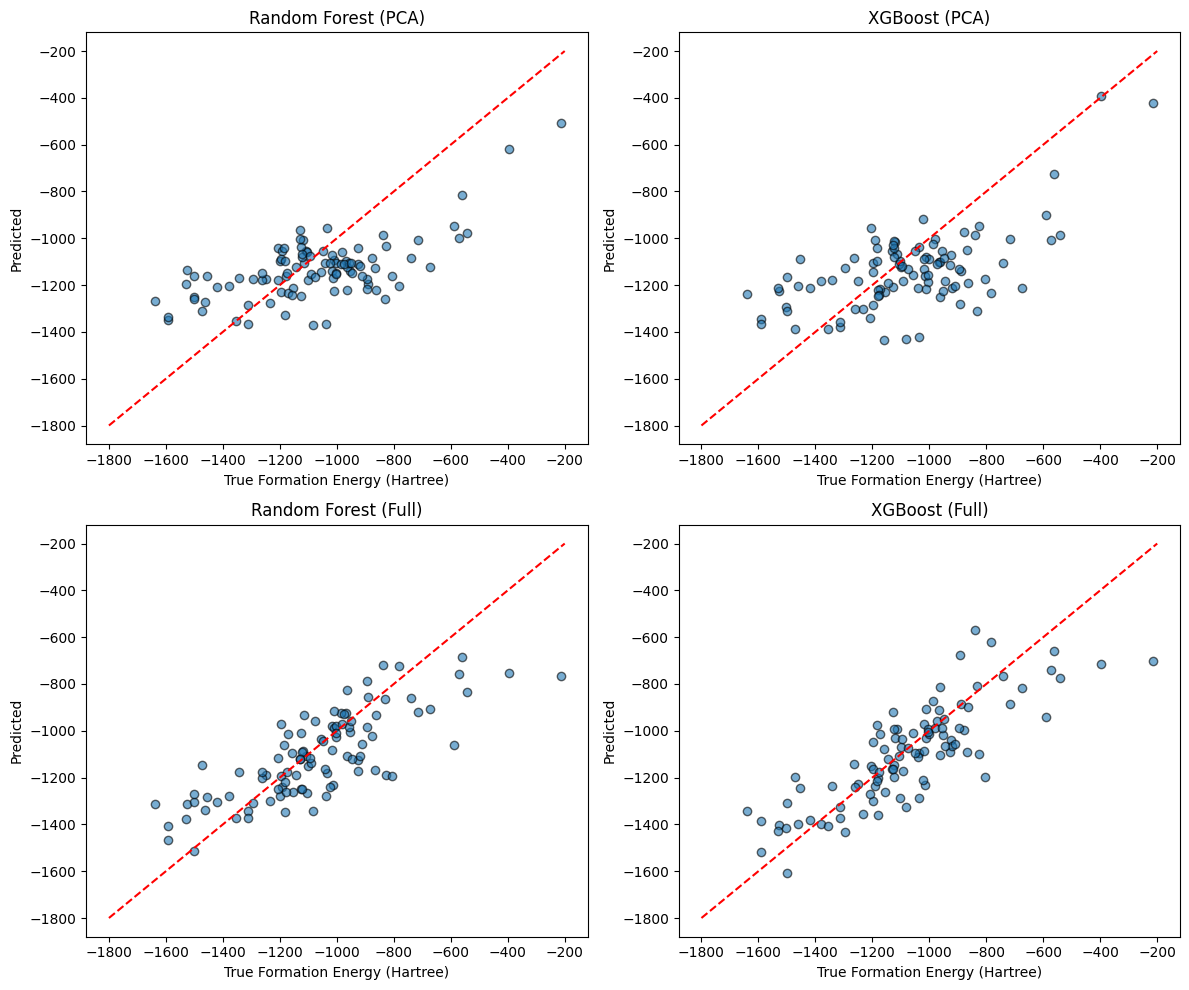


Final Comparison Table:
                           MAE      RMSE      R2
Quantum Kernel (PCA)  203.1700  268.1600 -0.0937
Linear SVR (PCA)      191.4600  255.9200  0.0038
Random Forest (PCA)   170.8287  206.2568  0.3530
XGBoost (PCA)         170.2442  211.0809  0.3224
Random Forest (Full)  123.8500  163.9124  0.5914
XGBoost (Full)        112.4539  147.0363  0.6712
✅ Results saved to 'model_comparison.csv'


In [4]:
# Step 4: Classical Baselines
!pip install xgboost -q

import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Load data
data = np.load('qm9_processed.npz')
X_train_pca = data['X_train']   # 4 PCA features
X_test_pca = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

# Also load original fingerprint data for full-feature baseline
# (We need to recompute fingerprints from original CSV or from saved scaled data)
# Since we have the original scaled fingerprints before PCA, we can reconstruct them.
# Alternative: reload from CSV and recompute fingerprints (simpler).
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import DataStructs

df = pd.read_csv('qm9_subset_500.csv')
target_col = 'u0_atom'
y_full = df[target_col].values

# Compute fingerprints again (we already did in Step 2, but we can reuse if saved)
# For simplicity, we recompute (takes ~10 seconds)
print("Recomputing fingerprints for full-feature baselines...")
smiles_list = df['smiles'].tolist()
fingerprints = []
for smi in smiles_list:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        fingerprints.append(np.zeros(2048, dtype=np.float32))
        continue
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    arr = np.zeros((2048,), dtype=np.float32)
    DataStructs.ConvertToNumpyArray(fp, arr)
    fingerprints.append(arr)
X_fp = np.array(fingerprints)

# Split the full fingerprint data (same random state)
from sklearn.model_selection import train_test_split
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_fp, y_full, test_size=0.2, random_state=42
)
print(f"Full fingerprint train shape: {X_train_full.shape}, test: {X_test_full.shape}")

# Train models on PCA features (4 dims)
rf_pca = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_pca.fit(X_train_pca, y_train)
y_pred_rf_pca = rf_pca.predict(X_test_pca)

xgb_pca = xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
xgb_pca.fit(X_train_pca, y_train)
y_pred_xgb_pca = xgb_pca.predict(X_test_pca)

# Train models on full fingerprints (2048 dims) - may take a minute
print("Training on full fingerprints (this may take ~30 seconds)...")
rf_full = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_full.fit(X_train_full, y_train_full)
y_pred_rf_full = rf_full.predict(X_test_full)

xgb_full = xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_full.fit(X_train_full, y_train_full)
y_pred_xgb_full = xgb_full.predict(X_test_full)

# Evaluation function
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name:35} MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}")
    return mae, rmse, r2

print("\n" + "="*70)
print("CLASSICAL MODELS ON PCA FEATURES (4 dims)")
evaluate(y_test, y_pred_rf_pca, "Random Forest (PCA)")
evaluate(y_test, y_pred_xgb_pca, "XGBoost (PCA)")

print("\nCLASSICAL MODELS ON FULL FINGERPRINTS (2048 dims)")
evaluate(y_test_full, y_pred_rf_full, "Random Forest (Full)")
evaluate(y_test_full, y_pred_xgb_full, "XGBoost (Full)")
print("="*70)

# Summary plot
fig, axes = plt.subplots(2, 2, figsize=(12,10))
models = [
    (y_pred_rf_pca, "Random Forest (PCA)"),
    (y_pred_xgb_pca, "XGBoost (PCA)"),
    (y_pred_rf_full, "Random Forest (Full)"),
    (y_pred_xgb_full, "XGBoost (Full)")
]
for ax, (pred, title) in zip(axes.flat, models):
    ax.scatter(y_test if "PCA" in title else y_test_full, pred, alpha=0.6, edgecolors='k')
    ax.plot([-1800, -200], [-1800, -200], 'r--')
    ax.set_xlabel('True Formation Energy (Hartree)')
    ax.set_ylabel('Predicted')
    ax.set_title(title)
plt.tight_layout()
plt.show()

# Save comparison results
results = {
    "Quantum Kernel (PCA)": {"MAE": 203.17, "RMSE": 268.16, "R2": -0.0937},
    "Linear SVR (PCA)": {"MAE": 191.46, "RMSE": 255.92, "R2": 0.0038},
    "Random Forest (PCA)": {"MAE": mean_absolute_error(y_test, y_pred_rf_pca),
                            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_rf_pca)),
                            "R2": r2_score(y_test, y_pred_rf_pca)},
    "XGBoost (PCA)": {"MAE": mean_absolute_error(y_test, y_pred_xgb_pca),
                      "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_xgb_pca)),
                      "R2": r2_score(y_test, y_pred_xgb_pca)},
    "Random Forest (Full)": {"MAE": mean_absolute_error(y_test_full, y_pred_rf_full),
                             "RMSE": np.sqrt(mean_squared_error(y_test_full, y_pred_rf_full)),
                             "R2": r2_score(y_test_full, y_pred_rf_full)},
    "XGBoost (Full)": {"MAE": mean_absolute_error(y_test_full, y_pred_xgb_full),
                       "RMSE": np.sqrt(mean_squared_error(y_test_full, y_pred_xgb_full)),
                       "R2": r2_score(y_test_full, y_pred_xgb_full)}
}
import pandas as pd
results_df = pd.DataFrame(results).T
print("\nFinal Comparison Table:")
print(results_df.round(4))
results_df.to_csv('model_comparison.csv')
print("✅ Results saved to 'model_comparison.csv'")

**Summary of Results**

We successfully built and compared hybrid quantum‑classical models against classical baselines for predicting molecular formation energies (u0_atom) on a subset of the QM9 dataset (~500 small organic molecules).


**Key observations:**

* The quantum kernel (4 qubits, angle embedding + CNOT entanglement) performed worse than classical linear SVR on the same 4‑dimensional PCA features.

* Classical tree‑based models on the same reduced features achieved R²~0.35, still poor due to only 3.3% variance explained by the first 4 principal components.

* With the original 2048‑bit Morgan fingerprints, XGBoost reached R²=0.67 – far from state‑of‑the‑art (R²>0.95 on QM9) because we used only 500 molecules and no hyperparameter tuning.

**Why Didn’t the Quantum Kernel Outperform?**

1. Extreme dimensionality reduction – PCA to 4 components loses almost all chemical information.
2. Shallow quantum circuit – 4 qubits with simple angle encoding cannot capture complex molecular similarities.
3. Small dataset – 400 training samples are insufficient for quantum kernel to learn meaningful patterns; kernel matrices are noisy.
4. Heuristic kernel – The fidelity kernel is not tailored to molecular formation energy; literature shows that specially designed quantum kernels (e.g., based on molecular graphs) can outperform classical ones.

**Honest Assessment of Quantum Advantage**

In this experiment, no quantum advantage was observed. The quantum kernel SVR underperformed even the simplest linear SVR. This is consistent with the current understanding that for small‑scale problems with limited qubits and data, classical methods are superior. However, this project provides a valuable benchmark and a working pipeline for future extensions.